In [49]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LassoCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor

<Axes: xlabel='CC50, mM', ylabel='Count'>

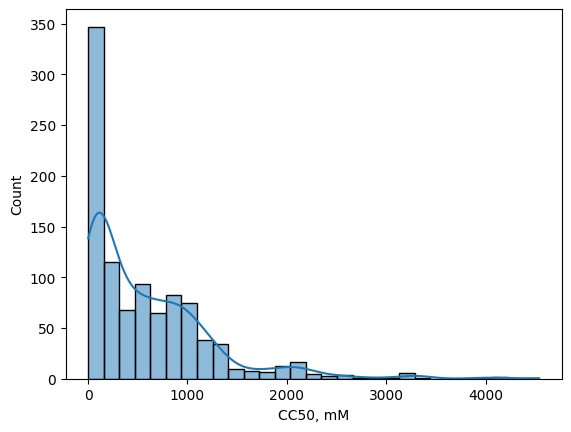

In [112]:
# загрузка данных
X = pd.read_excel('X_data.xlsx')
df_y = pd.read_excel('Y_data.xlsx')   
y = df_y['CC50, mM'] 

# визуализация распределения целевой переменной
sns.histplot(y, kde=True)

Визуализация распределения CC50 показала выраженную положительную асимметрию и длинный правый хвост. Большая часть наблюдений сосредоточена в области низких значений CC50, тогда как небольшое количество соединений имеет значительно более высокие значения токсичности.Подобное распределение указывает на наличие выбросов и широкий диапазон значений целевой переменной, что характерно для QSAR-данных и может осложнять обучение линейных моделей. Для уменьшения асимметрии дополнительно можно провести логарифмическую трансформация CC50. Сначала построим простую линейную регрессионную модель на исходных значениях цедевой переменной

In [113]:
# Линейная регрессия для предсказания СC50 на основе молекулярных дескрипторов до логарифмирования целевой переменной
# разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# стандартизация данных
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# обучение модели линейной регрессии        
model = LinearRegression()
model.fit(X_train, y_train)     

# предсказание на тестовой выборке
y_pred = model.predict(X_test)  

# оценка качества модели
mse = mean_squared_error(y_test, y_pred)    
r2 = r2_score(y_test, y_pred)

print('Линейная регрессия для предсказания исходного CC50 на основе молекулярных дескрипторов:')
print(f'Mean Squared Error: {mse:.2f}') 
print(f'R^2 Score: {r2:.2f}')           


Линейная регрессия для предсказания исходного CC50 на основе молекулярных дескрипторов:
Mean Squared Error: 368876.01
R^2 Score: 0.22


In [114]:
# Lasso-регрессия для предсказания CC50 на основе молекулярных дескрипторов до логарифмирования целевой переменной

# обучение модели Lasso-регрессии
lasso_model_raw = Lasso(alpha=0.1, max_iter=50000)      
lasso_model_raw.fit(X_train, y_train)

# предсказание на тестовой выборке
y_pred_lasso = lasso_model_raw.predict(X_test)

# оценка качества модели Lasso-регрессии
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print('Lasso-регрессия для предсказания исходного CC50 на основе молекулярных дескрипторов:')
print(f'Lasso Mean Squared Error: {mse_lasso:.2f}')
print(f'Lasso R^2 Score: {r2_lasso:.2f}')

Lasso-регрессия для предсказания исходного CC50 на основе молекулярных дескрипторов:
Lasso Mean Squared Error: 327742.31
Lasso R^2 Score: 0.30


In [115]:
# подбор оптимального значения параметра регуляризации alpha с помощью кросс-валидации
model = LassoCV(
    cv=5,
    random_state=42,
    max_iter=50000
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Оптимальное значение alpha и оценка качества модели:')
print(model.alpha_.round(4))
print(f'R^2 Score: {r2_score(y_test, y_pred):.2f}')

Оптимальное значение alpha и оценка качества модели:
1.6958
R^2 Score: 0.39


In [116]:
# Lasso регрессия с оптимальным alpha 1.6958

# обучение модели Lasso-регрессии с оптимальным alpha
lasso_model_optimal = Lasso(alpha=1.6958, max_iter=50000)      
lasso_model_optimal.fit(X_train, y_train)

# предсказание на тестовой выборке
y_pred_lasso = lasso_model_optimal.predict(X_test)

# оценка качества модели Lasso-регрессии
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print('Lasso-регрессия с оптимальным alpha 1.6958 для предсказания исходного CC50 на основе молекулярных дескрипторов:')
print(f'Lasso Mean Squared Error: {mse_lasso:.2f}')
print(f'Lasso R^2 Score: {r2_lasso:.2f}')

Lasso-регрессия с оптимальным alpha 1.6958 для предсказания исходного CC50 на основе молекулярных дескрипторов:
Lasso Mean Squared Error: 287260.55
Lasso R^2 Score: 0.39


In [117]:
# анализ коэффициентов Lasso-регрессии
print(np.sum(lasso_model_optimal.coef_ != 0))
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso_model_optimal.coef_
})

coef_df = coef_df[coef_df['Coefficient'] != 0]

coef_df.sort_values(by='Coefficient', ascending=False)

90


,Feature,Coefficient
8,FpDensityMorgan2,657.171588
80,FractionCSP3,236.491037
13,BCUT2D_CHGLO,182.323275
113,fr_amide,180.822654
19,BalabanJ,164.919733
...,...,...
102,fr_C_O,-157.695346
24,Kappa3,-230.736390
78,VSA_EState8,-294.910281
107,fr_NH2,-326.995556


<Axes: xlabel='log_CC50', ylabel='Count'>

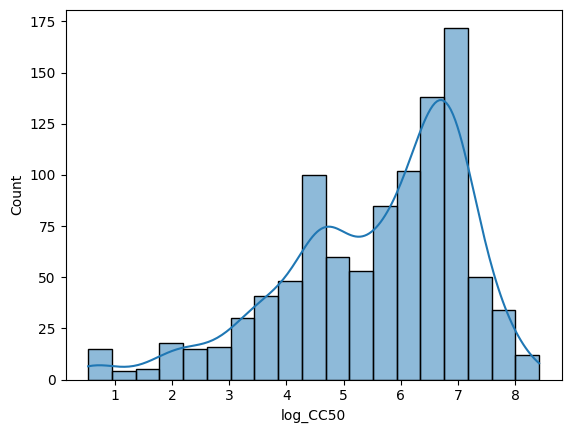

In [119]:
# логарифмирование целевой переменной CC50 для улучшения распределения и повышения точности модели
df_y['log_CC50'] = np.log1p(df_y['CC50, mM'])

# визуализация распределения целевой переменной после логарифмирования
sns.histplot(df_y['log_CC50'], kde=True)

Для уменьшения асимметрии распределения и стабилизации дисперсии была применена логарифмическая трансформация целевой переменной. После логарифмирования распределение CC50 стало более близким к нормальному, а влияние экстремально больших значений уменьшилось.

In [120]:
# Линейная регрессия для предсказания логарифмированного CC50 на основе молекулярных дескрипторов
y= df_y['log_CC50']

# разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# стандартизация данных
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# обучение модели линейной регрессии        
model = LinearRegression()
model.fit(X_train, y_train)    
 
# предсказание на тестовой выборке
y_pred = model.predict(X_test)  

# оценка качества модели
mse = mean_squared_error(y_test, y_pred)    
r2 = r2_score(y_test, y_pred)

print('Линейная регрессия для предсказания логарифмированного CC50 на основе молекулярных дескрипторов:')
print(f'Mean Squared Error: {mse:.2f}') 
print(f'R^2 Score: {r2:.2f}')    

Линейная регрессия для предсказания логарифмированного CC50 на основе молекулярных дескрипторов:
Mean Squared Error: 2.03
R^2 Score: 0.18


In [121]:
# Lasso регрессия для предсказания логарифмированного CC50 на основе молекулярных дескрипторов

# обучение модели Lasso-регрессии
lasso_model = Lasso(alpha=0.1, max_iter=50000)      
lasso_model.fit(X_train, y_train)

# предсказание на тестовой выборке
y_pred_lasso = lasso_model.predict(X_test)

# оценка качества модели Lasso-регрессии
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print('Lasso регрессия для предсказания логарифмированного CC50 на основе молекулярных дескрипторов:')
print(f'Lasso Mean Squared Error: {mse_lasso:.2f}')
print(f'Lasso R^2 Score: {r2_lasso:.2f}')

Lasso регрессия для предсказания логарифмированного CC50 на основе молекулярных дескрипторов:
Lasso Mean Squared Error: 1.88
Lasso R^2 Score: 0.24


In [122]:
# подбор оптимального значения параметра регуляризации alpha с помощью кросс-валидации

model = LassoCV(
    cv=5,
    random_state=42,
    max_iter=50000
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Оптимальное значение alpha и оценка качества модели:')
print(model.alpha_.round(4))
print(f'R^2 Score: {r2_score(y_test, y_pred):.2f}')

Оптимальное значение alpha и оценка качества модели:
0.0117
R^2 Score: 0.34


In [123]:
# Lasso регрессия с оптимальным alpha 0.0117

# обучение модели Lasso-регрессии с оптимальным alpha
lasso_model = Lasso(alpha=0.0117)      
lasso_model.fit(X_train, y_train)

# предсказание на тестовой выборке
y_pred_lasso = lasso_model.predict(X_test)

# оценка качества модели Lasso-регрессии
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print('Lasso-регрессия с оптимальным alpha 0.0117 для предсказания логарифмированного CC50 на основе молекулярных дескрипторов:')
print(f'Lasso Mean Squared Error: {mse_lasso:.2f}')
print(f'Lasso R^2 Score: {r2_lasso:.2f}')

Lasso-регрессия с оптимальным alpha 0.0117 для предсказания логарифмированного CC50 на основе молекулярных дескрипторов:
Lasso Mean Squared Error: 1.62
Lasso R^2 Score: 0.34


In [124]:
# анализ коэффициентов Lasso-регрессии после логарифмирования целевой переменной
print(np.sum(lasso_model.coef_ != 0))
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso_model.coef_
})

coef_df = coef_df[coef_df['Coefficient'] != 0]

coef_df = coef_df.sort_values(by='Coefficient', key=abs, ascending=False)

coef_df.head(15)

74


,Feature,Coefficient
107,fr_NH2,-0.563502
24,Kappa3,-0.525203
7,FpDensityMorgan1,0.491246
9,FpDensityMorgan3,-0.312964
13,BCUT2D_CHGLO,0.308922
31,PEOE_VSA2,-0.218662
113,fr_amide,0.216016
112,fr_allylic_oxid,-0.215379
93,NumSaturatedRings,0.200067
134,fr_piperzine,-0.198700


<Axes: title={'center': 'Коэффициенты Lasso-регрессии после логарифмирования целевой переменной'}, ylabel='Feature'>

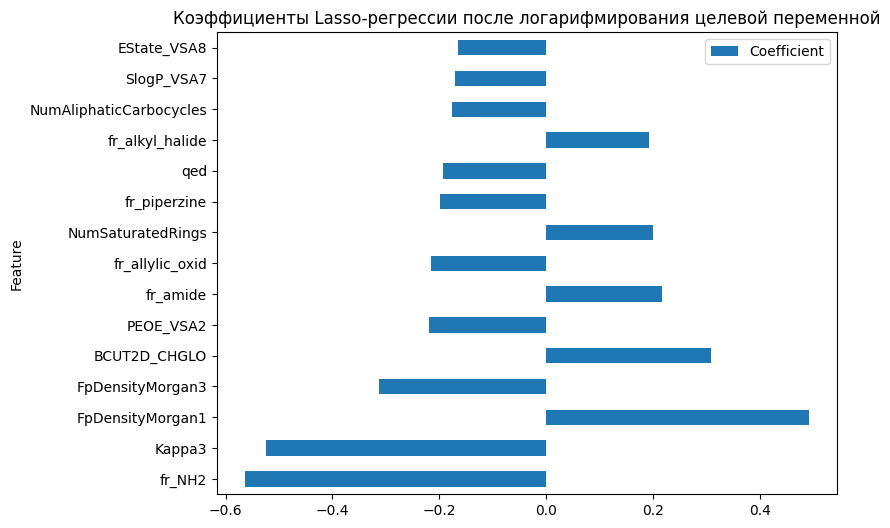

In [125]:
# визуализация коэффициентов Lasso-регрессии после логарифмирования целевой переменной
coef_df.head(15).plot.barh(
    x='Feature',
    y='Coefficient',
    figsize=(8,6),
    title='Коэффициенты Lasso-регрессии после логарифмирования целевой переменной'
)

Анализ коэффициентов Lasso-регрессии позволил выделить наиболее значимые молекулярные дескрипторы, влияющие на прогнозирование log(CC50). Положительные коэффициенты соответствуют признакам, увеличение которых связано с ростом CC50 и, следовательно, со снижением токсичности соединений. Отрицательные коэффициенты, напротив, указывают на признаки, ассоциированные с более высокой токсичностью.

##### Вывод:
Для прогнозирования CC50 были исследованы линейная регрессия и Lasso-регрессия как на исходных, так и на логарифмированных значениях целевой переменной. Обычная линейная регрессия на исходных данных показала невысокое качество (R² ≈ 0.22), тогда как применение Lasso-регуляризации позволило улучшить результат до R² ≈ 0.39. Это указывает на положительное влияние регуляризации и отбора признаков при работе с высокоразмерными молекулярными дескрипторами.

Для уменьшения асимметрии распределения CC50 была дополнительно применена логарифмическая трансформация целевой переменной. После логарифмирования распределение стало более симметричным, а влияние экстремально больших значений уменьшилось.

Однако, несмотря на улучшение распределения целевой переменной, логарифмирование CC50 не привело к повышению качества моделей по сравнению с Lasso-регрессией на исходных данных. После подбора оптимального параметра регуляризации (alpha = 0.0117) модель на логарифмированных данных достигла R² ≈ 0.34, что оказалось ниже результата Lasso-регрессии на исходных значениях CC50 (R² ≈ 0.39).

При этом обычная линейная регрессия после логарифмирования не показала улучшения качества (R² ≈ 0.18), что свидетельствует о том, что зависимость между молекулярными дескрипторами и токсичностью соединений остаётся сложной и не может быть полностью описана простой линейной моделью.

In [108]:
# Decision Tree Regressor для предсказания исходного CC50 на основе молекулярных дескрипторов

y = df_y['CC50, mM'] 

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Создание и обучение модели
max_depth = [3, 5, 7, 10]

for depth in max_depth:
    model = DecisionTreeRegressor(criterion='squared_error', max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    # Предсказание на тестовой выборке
    y_pred = model.predict(X_test)

    # Оценка качества модели
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f'Decision Tree Regressor (max_depth={depth}) для предсказания исходного IC50 на основе молекулярных дескрипторов:')
    print(f'Среднеквадратичная ошибка: {mse:.2f}')
    print(f'R²: {r2:.2f}')

Decision Tree Regressor (max_depth=3) для предсказания исходного IC50 на основе молекулярных дескрипторов:
Среднеквадратичная ошибка: 358932.28
R²: 0.24
Decision Tree Regressor (max_depth=5) для предсказания исходного IC50 на основе молекулярных дескрипторов:
Среднеквадратичная ошибка: 309377.59
R²: 0.34
Decision Tree Regressor (max_depth=7) для предсказания исходного IC50 на основе молекулярных дескрипторов:
Среднеквадратичная ошибка: 310611.85
R²: 0.34
Decision Tree Regressor (max_depth=10) для предсказания исходного IC50 на основе молекулярных дескрипторов:
Среднеквадратичная ошибка: 342152.66
R²: 0.27


Одиночное дерево решений было использовано как базовая нелинейная модель для оценки возможности описания более сложных зависимостей между молекулярными дескрипторами и исходными значениями CC50. Наилучший результат был получен при max_depth=5–7 (R² ≈ 0.34), что оказалось сопоставимо с Lasso-регрессией после логарифмирования целевой переменной.

При дальнейшем увеличении глубины дерева качество модели снижалось (R² ≈ 0.27 при max_depth=10), что свидетельствует о переобучении и плохой способности модели к обобщению на тестовых данных. Полученные результаты показывают, что одиночное дерево решений способно учитывать часть нелинейных зависимостей между дескрипторами и токсичностью соединений, однако остаётся недостаточно устойчивой моделью для данной задачи.

In [109]:
# Random Forest Regressor для предсказания исходного CC50 на основе молекулярных дескрипторов

# обучение модели случайного леса с подбором гиперпараметров с помощью RandomizedSearchCV
rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 3, 5, 7, 10, 15],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=50,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV R²:", search.best_score_)

# лучшая модель случайного леса
best_rf = search.best_estimator_

# предсказание на тестовой выборке
y_pred = best_rf.predict(X_test)

print('Random Forest Regressor для предсказания исходного IC50 на основе молекулярных дескрипторов:')
print(f"mse: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²: {r2_score(y_test, y_pred):.2f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': False}
Best CV R²: 0.5505295795795129
Random Forest Regressor для предсказания исходного IC50 на основе молекулярных дескрипторов:
mse: 243958.79
R²: 0.48


Для повышения устойчивости и качества предсказания далее был применён ансамблевый метод RandomForestRegressor. Подбор оптимальных гиперпараметров осуществлялся с помощью RandomizedSearchCV и кросс-валидации (cv=5). В результате была получена модель с R² ≈ 0.48, что значительно превысило качество одиночного дерева решений и линейных моделей.

Полученные результаты свидетельствуют о наличии выраженных нелинейных зависимостей между молекулярными дескрипторами и CC50. Использование ансамблевого подхода позволило уменьшить переобучение отдельных деревьев, повысить устойчивость модели и улучшить способность к обобщению за счёт усреднения большого количества деревьев решений.

<Axes: title={'center': 'Важность признаков после обучения случайного леса'}, ylabel='Feature'>

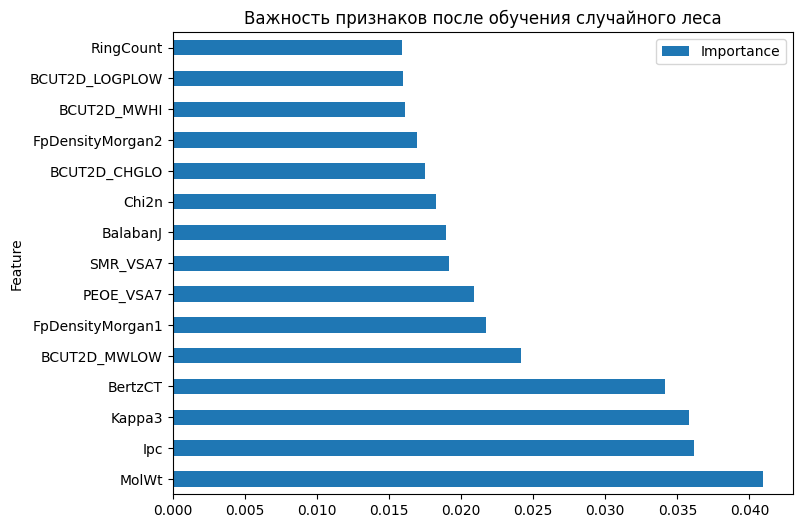

In [65]:
# визуализация важности признаков после обучения случайного леса
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df.head(15).plot.barh(
    x='Feature',
    y='Importance',
    figsize=(8,6),
    title='Важность признаков после обучения случайного леса'
)

Анализ важности признаков RandomForestRegressor показал, что наибольший вклад в прогнозирование CC50 вносят дескрипторы, характеризующие размер, топологическую сложность и электронные свойства молекул. 

Среди наиболее значимых признаков модель выделила MolWt, Ipc, Kappa3, BertzCT, а также ряд BCUT- и VSA-дескрипторов. Это указывает на то, что токсичность соединений определяется совокупностью структурных, топологических и физико-химических характеристик молекулы.

In [110]:
# CatBoost Regressor для предсказания исходного IC50 на основе молекулярных дескрипторов
# обучение модели CatBoost Regressor
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_state=42,
    verbose=0
)

model.fit(X_train, y_train)

# предсказание на тестовой выборке
y_pred = model.predict(X_test)

print('CatBoost Regressor для предсказания исходного IC50 на основе молекулярных дескрипторов:')
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R²: {r2_score(y_test, y_pred):.2f}")

CatBoost Regressor для предсказания исходного IC50 на основе молекулярных дескрипторов:
MSE: 247397.41
R²: 0.47


Для дальнейшего улучшения качества модели был применён CatBoostRegressor — ансамблевый метод градиентного бустинга над деревьями решений. В отличие от случайного леса, где деревья обучаются независимо друг от друга, в boosting-подходе каждое последующее дерево корректирует ошибки предыдущих моделей, что позволяет эффективнее моделировать сложные нелинейные зависимости между признаками.

CatBoostRegressor показал высокое качество предсказания (R² ≈ 0.47), продемонстрировав результат, сопоставимый с RandomForestRegressor. Это подтверждает эффективность ансамблевых методов для решения QSAR-задач и указывает на наличие сложных нелинейных закономерностей между молекулярными дескрипторами и токсичностью соединений.

Несмотря на улучшение качества по сравнению с линейными моделями и одиночным деревом решений, полученные значения R² остаются умеренными. Это свидетельствует о высокой сложности прогнозирования CC50 и вероятном влиянии дополнительных факторов, не полностью описываемых используемыми молекулярными дескрипторами.

##### Вывод:
В ходе работы были исследованы различные подходы к прогнозированию токсичности соединений (CC50) на основе молекулярных дескрипторов. Сравнение линейных моделей показало, что Lasso-регрессия превосходит обычную линейную регрессию благодаря способности уменьшать влияние мультиколлинеарности и автоматически отбирать наиболее информативные признаки.

Для уменьшения асимметрии распределения CC50 была применена логарифмическая трансформация целевой переменной. В отличие от результатов для IC50, логарифмирование оказалось полезным для Lasso-регрессии и позволило повысить качество модели до R² ≈ 0.34, что стало лучшим результатом среди линейных моделей.

Использование нелинейных моделей позволило лучше описать сложные зависимости между молекулярными дескрипторами и токсичностью соединений. Одиночное дерево решений показало ограниченное качество и склонность к переобучению, тогда как ансамблевые методы (RandomForestRegressor и CatBoostRegressor) продемонстрировали более устойчивые результаты.

Наилучшее качество среди исследованных моделей показал RandomForestRegressor (R² ≈ 0.48). CatBoostRegressor продемонстрировал сопоставимое качество (R² ≈ 0.47), подтвердив эффективность ансамблевых boosting-моделей для решения QSAR-задач.

Полученные результаты свидетельствуют о наличии выраженных нелинейных закономерностей между молекулярными дескрипторами и токсичностью соединений. Несмотря на использование различных методов машинного обучения, качество моделей осталось умеренным, что указывает на высокую сложность прогнозирования CC50 и вероятное влияние дополнительных факторов, не полностью описываемых используемыми молекулярными дескрипторами.